In [1]:
#import torch functions and util modules
import torch
import torch.nn.functional as F
from torch import nn
import matplotlib.pyplot as plt
from torcheval.metrics.functional import multiclass_f1_score
from torchvision.utils import flow_to_image
from tqdm import trange


/Users/mattias/Downloads/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
#read in provided ct and seg slice data
ct_slice, seg_slice = torch.load('ct_seg_slice.pth')['ct_slice'], torch.load('ct_seg_slice.pth')['seg_slice']

In [3]:
#load the DINOv2 model from torch hub and run inference on twice upsampled inputs
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
with torch.no_grad():
    features_dict = model.forward_features(F.interpolate(ct_slice,scale_factor=2,mode='bilinear',align_corners=False))
    patch_tokens = features_dict["x_norm_patchtokens"]
print(patch_tokens.shape) #should be 9, 1849, 384

Using cache found in /Users/mattias/.cache/torch/hub/facebookresearch_dinov2_main
/Users/mattias/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/mattias/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/mattias/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


torch.Size([9, 1849, 384])


In [4]:
class CoordinateTranslator(nn.Module):
    def __init__(self):
        super().__init__()
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, query, key, value, mask=None):
        # query, key, value shape: [B, N, C] -> e.g., [9, 1849, 384]
        attention = torch.matmul(query, key.transpose(-1, -2)) # [9, 1849, 1849]
        if mask is not None:
            attention = attention.masked_fill(mask.unsqueeze(0) == 0, float('-inf'))
        attention = self.softmax(attention)
        out = torch.matmul(attention, value)                 # [9, 1849, 384]
        return out

In [5]:
#create a local attention mask of size 7x7 for CoordinateTranslator
grid_voxel = torch.stack(torch.meshgrid(torch.arange(43), torch.arange(43)), dim=-1).reshape(-1, 2) # [1849, 2]
dist = torch.cdist(grid_voxel.float(), grid_voxel.float(), p=2) # [1849, 1849]

#build smoothing function with two 3x3 avg pooling layers (stride=1)
def smooth(flow):
    # Apply a simple smoothing filter to the flow field
    return F.avg_pool2d(F.avg_pool2d(flow.permute(0, 3, 1, 2), kernel_size=3, stride=1, padding=1), kernel_size=3, stride=1, padding=1).permute(0, 2, 3, 1)

#make a list of all pairings without 5,6,7 (validation)
case_pairs = []
for i in range(9):
    for j in range(9):
        if i != j and i not in [5, 6, 7] and j not in [5, 6, 7]:
            case_pairs.append((i, j))
print(len(case_pairs), case_pairs)  # Should contain 30 pairings

30 [(0, 1), (0, 2), (0, 3), (0, 4), (0, 8), (1, 0), (1, 2), (1, 3), (1, 4), (1, 8), (2, 0), (2, 1), (2, 3), (2, 4), (2, 8), (3, 0), (3, 1), (3, 2), (3, 4), (3, 8), (4, 0), (4, 1), (4, 2), (4, 3), (4, 8), (8, 0), (8, 1), (8, 2), (8, 3), (8, 4)]


/Users/mattias/Downloads/.venv/lib/python3.12/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4223.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


/var/folders/h6/cjc2wp8x67309lnxnt_988380000gn/T/ipykernel_10221/784184547.py:2: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  grid = F.affine_grid(torch.eye(2, 3)[None], (1, 1, 43, 43)).flatten(1, 2)  # [1849, 2]
/var/folders/h6/cjc2wp8x67309lnxnt_988380000gn/T/ipykernel_10221/784184547.py:3: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  grid_hr = F.affine_grid(torch.eye(2, 3)[None], (1, 1, 301, 301)).flatten(1, 2)


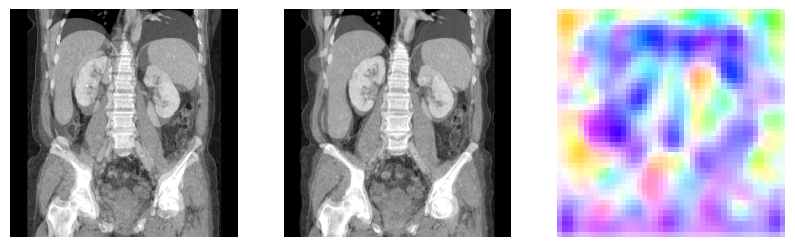

Validation results with mask
Average DICE before: 0.5092918872833252
Average DICE after: 0.632124125957489


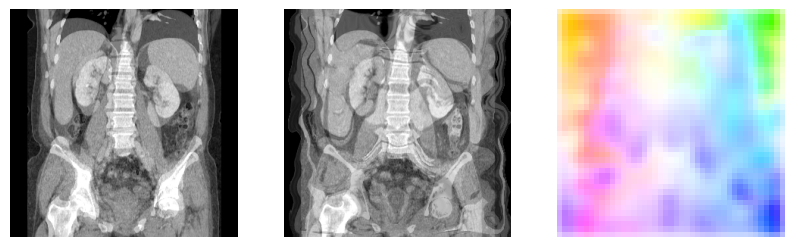

Validation results without mask
Average DICE before: 0.5092918872833252
Average DICE after: 0.20498527586460114


In [6]:
#create a grid (+1/-1) for the 43x43 patch tokens and a grid for the 301x301 CT slices
grid = F.affine_grid(torch.eye(2, 3)[None], (1, 1, 43, 43)).flatten(1, 2)  # [1849, 2]
grid_hr = F.affine_grid(torch.eye(2, 3)[None], (1, 1, 301, 301)).flatten(1, 2)
translator = CoordinateTranslator()

for use_mask in (True, False):
    all_dices = []; all_dices_before = []
    for case_pair in ((5, 6), (6, 7), (5, 7), (6, 5), (7, 6), (7, 5)):
        A = case_pair[0]
        B = case_pair[1]
        #print(f"Registering from case {A} to case {B}")
        mask =  torch.zeros((1849, 1849), dtype=torch.bool)
        mask[dist < 7] = True  # Set True for distances greater than xx
        if not use_mask:
            mask = None
        with torch.no_grad():
            output = translator(patch_tokens[A:A+1].div(10),patch_tokens[B:B+1].div(10),grid, mask) 
        flow = smooth((output - grid).unflatten(1,[43,43]))  # Subtract the original grid to get the flow
        flow_hr = F.interpolate(flow.permute(0, 3, 1, 2), size=(301, 301), mode='bilinear', align_corners=False).permute(0, 2, 3, 1)#.flatten(1, 2)

        if(A==6 and B==7):
            flow_img = flow_to_image(flow[0].permute(2, 0, 1))

            warped = F.grid_sample(ct_slice[B:B+1], flow_hr + grid_hr.reshape(1, 301, 301, 2), align_corners=False)
            f,ax = plt.subplots(1,3,figsize=(10,5))
            ax[0].imshow(ct_slice[A,0].data+ct_slice[B,0].data, cmap='gray'); ax[0].axis('off')
            ax[1].imshow(warped[0,0].data+ct_slice[A,0].data, cmap='gray'); ax[1].axis('off')
            ax[2].imshow(flow_img.permute(1, 2, 0)); ax[2].axis('off')
            plt.show()

        warped_seg = F.grid_sample(seg_slice[B:B+1].unsqueeze(1).float(), flow_hr + grid_hr.reshape(1, 301, 301, 2), align_corners=False, mode='nearest').long().squeeze(1)
        dice_before = multiclass_f1_score(seg_slice[A].reshape(-1), seg_slice[B].reshape(-1), num_classes=8, average=None)
        all_dices_before.append(dice_before)
        dice_after = multiclass_f1_score(seg_slice[A].reshape(-1), warped_seg[0].reshape(-1), num_classes=8, average=None)
        all_dices.append(dice_after)
    print("Validation results with mask" if use_mask else "Validation results without mask")
    print(f"Average DICE before: {torch.stack(all_dices_before).mean()}")
    print(f"Average DICE after: {torch.stack(all_dices).mean()}")

In [ ]:
#BONUS train a mapping from the 384-dim patch tokens to more registration specific 128-dim features using a simple MLP and the same CoordinateTranslator architecture. Use the 5,6,7 cases for validation and the other 6 cases for training. Report DICE scores before and after registration on the validation set.

class FeatureMLP(nn.Module):
    def __init__(self, in_dim=384, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(),
            nn.Linear(256, out_dim)
        )

    def forward(self, x):
        return self.net(x)

feature_mlp = FeatureMLP()
optimizer = torch.optim.Adam(feature_mlp.parameters(), lr=1e-3)
train_translator = CoordinateTranslator()

train_mask = torch.zeros((1849, 1849), dtype=torch.bool)
train_mask[dist < 7] = True

num_epochs = 50
for epoch in trange(num_epochs):
    epoch_loss = 0.0
    for A, B in case_pairs:
        optimizer.zero_grad()
        feat_A = feature_mlp(patch_tokens[A:A+1].div(10))
        feat_B = feature_mlp(patch_tokens[B:B+1].div(10))

        output = train_translator(feat_A, feat_B, grid, train_mask)
        flow_train = smooth((output - grid).unflatten(1, [43, 43]))
        flow_hr_train = F.interpolate(flow_train.permute(0, 3, 1, 2), size=(301, 301),
                                       mode='bilinear', align_corners=False).permute(0, 2, 3, 1)

        warped_seg_train = F.grid_sample(
            seg_slice[B:B+1].unsqueeze(1).float(),
            flow_hr_train + grid_hr.reshape(1, 301, 301, 2),
            align_corners=False, mode='nearest'
        ).long().squeeze(1)

        # Use a soft proxy loss: warp CT image instead of seg for differentiability
        #warped_ct_train = F.grid_sample(
        #    ct_slice[B:B+1],
        #    flow_hr_train + grid_hr.reshape(1, 301, 301, 2),
        #    align_corners=False
        #)
        #loss = F.mse_loss(warped_ct_train, ct_slice[A:A+1])

        #initial LLM suggestion changed to supervised training on segmentation labels for better performance
        seg_slice_onehot = F.one_hot(seg_slice[B], num_classes=8).permute(2, 0, 1).float().unsqueeze(0)  # [1, 8, 301, 301]
        warped_seg_onehot = F.grid_sample(seg_slice_onehot, flow_hr_train + grid_hr.reshape(1, 301, 301, 2), align_corners=False, mode='bilinear')
        loss = F.cross_entropy(warped_seg_onehot, seg_slice[A].unsqueeze(0), reduction='mean')

        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(case_pairs):.4f}")


 10%|█         | 10/100 [00:03<00:34,  2.64it/s]

Epoch 10/100, Loss: 1.3361


 20%|██        | 20/100 [00:07<00:30,  2.61it/s]

Epoch 20/100, Loss: 1.3282


 30%|███       | 30/100 [00:11<00:26,  2.64it/s]

...

Epoch 80/100, Loss: 1.3104


 90%|█████████ | 90/100 [00:34<00:03,  2.58it/s]

Epoch 90/100, Loss: 1.3087


100%|██████████| 100/100 [00:38<00:00,  2.60it/s]

Epoch 100/100, Loss: 1.3087


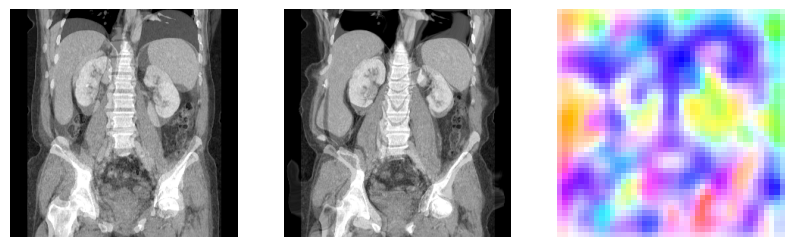

Validation Average DICE before: 0.5092918872833252
Validation Average DICE after: 0.67698073387146


In [8]:

# Validation on cases 5, 6, 7
feature_mlp.eval()
val_dices_before = []
val_dices_after = []
with torch.no_grad():
    for A, B in ((5, 6), (6, 7), (5, 7), (6, 5), (7, 6), (7, 5)):
        feat_A = feature_mlp(patch_tokens[A:A+1].div(10))
        feat_B = feature_mlp(patch_tokens[B:B+1].div(10))

        output = train_translator(feat_A, feat_B, grid, train_mask)
        flow_val = smooth((output - grid).unflatten(1, [43, 43]))
        flow_hr_val = F.interpolate(flow_val.permute(0, 3, 1, 2), size=(301, 301),
                                     mode='bilinear', align_corners=False).permute(0, 2, 3, 1)

        warped_seg_val = F.grid_sample(
            seg_slice[B:B+1].unsqueeze(1).float(),
            flow_hr_val + grid_hr.reshape(1, 301, 301, 2),
            align_corners=False, mode='nearest'
        ).long().squeeze(1)

        dice_before_val = multiclass_f1_score(seg_slice[A].reshape(-1), seg_slice[B].reshape(-1), num_classes=8, average=None)
        dice_after_val = multiclass_f1_score(seg_slice[A].reshape(-1), warped_seg_val[0].reshape(-1), num_classes=8, average=None)
        val_dices_before.append(dice_before_val)
        val_dices_after.append(dice_after_val)

        if(A==6 and B==7):
            flow_img_val = flow_to_image(flow_val[0].permute(2, 0, 1))
            warped_val = F.grid_sample(ct_slice[B:B+1], flow_hr_val + grid_hr.reshape(1, 301, 301, 2), align_corners=False)
            f, ax = plt.subplots(1, 3, figsize=(10, 5))
            ax[0].imshow(ct_slice[A, 0].data + ct_slice[B, 0].data, cmap='gray'); ax[0].axis('off')
            ax[1].imshow(warped_val[0, 0].data + ct_slice[A, 0].data, cmap='gray'); ax[1].axis('off')
            ax[2].imshow(flow_img_val.permute(1, 2, 0)); ax[2].axis('off')
            plt.show()

print(f"Validation Average DICE before: {torch.stack(val_dices_before).mean()}")
print(f"Validation Average DICE after: {torch.stack(val_dices_after).mean()}")